# Single Layer Perceptron
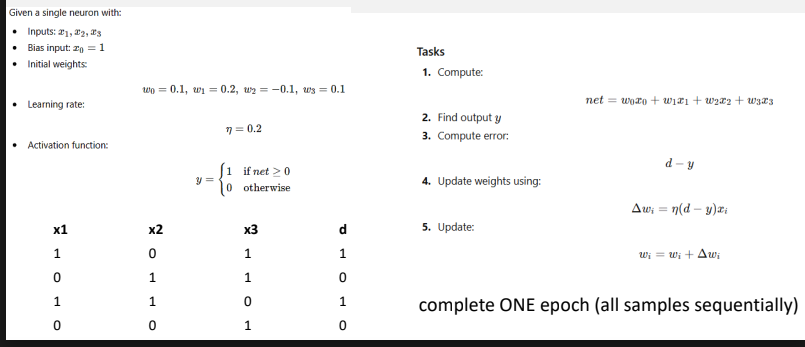


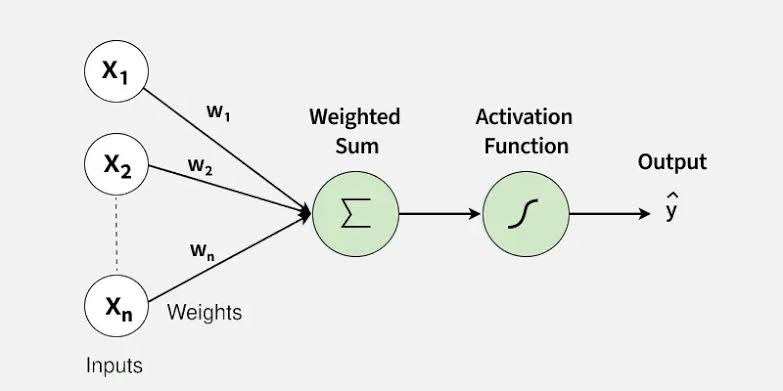

In [ ]:
# PERCEPTRON IMPLEMENTATION V 0.0
# bare bones implementation with hard coded values (no classes)
def net_func(x0, x1, x2, x3):
  return ((w0*x0) + (x1*w1) + (x2*w2) + (x3*w3))


def activation(net):
  if net>=0:
    return 1
  else:
    return 0

def error_func(d, y):
  return (d - y)

def delta(error, xi):
  if(y!=d):
    return (eta*error*xi)
  else:
    return 0.0



x0=1; w0=0.1
x1=[1, 0, 1, 0]; w1=0.2
x2=[0, 1, 1, 0]; w2=-0.1
x3=[1, 1, 0, 1]; w3=0.1
d =[1, 0, 1, 0]; eta = 0.2


epochs = 3
for epoch in range(epochs):
 y_list = list()
 print("Epoch:", epoch+1)
 for i in range(len(d)):
    net = net_func(x0, x1[i], x2[i], x3[i])
    y = activation(net)
    y_list.append(y)
    error = error_func(d[i], y)
    delta0, delta1, delta2, delta3 = delta(error,x0), delta(error, x1[i]), delta(error, x2[i]), delta(error, x3[i])
    w0, w1, w2, w3 = (w0+delta0), (w1+delta1), (w2+delta2), (w3+delta3)

    print("Sample", i+1)
    print("[w0, w1, w2, w3] = ", [w0, w1, w2, w3])


 print("Exp =", d)
 print("Calc =", y_list)
 print("\n\n")

In [ ]:
## PERCEPTRON IMPLEMENTATION V 1.0
## LOGIC AND DESIGN ERRORS IN THIS VERSION

# Using classes (similar to PyTorch)--> brute force version
class perceptron:
  # initial values same as the example above
  # cuz im too retarded to figure out how to make this dynamic
  epochs = 3
  eta = 0.2
  inputs = [
  # [1, 0, 1, 0],
  # [0, 1, 1, 0],
  # [1, 1, 0, 1]
  [1, 0, 1],
  [0, 1, 1],
  [1, 1, 0],
  [0, 0, 1]
  ]
  weights = [0.2, -0.1, 0.1]
  bias = 0.1

  def __init__(self, learning_rate):
    # initialise learning rate
    self.eta = learning_rate

  def forward(self, x): # takes a list x of feature values as an input i.e x = [x1, x2, x3,... xn]. Returns activation result.
    # net() --> activation() --> prediction

    # net()
    net = self.bias
    for i in range(len(x)):
      net=net+(x[i]*self.weights[i])

    # activation()
    if net>=0:
      return 1
    else:
      return 0


# len(x) => number of training samples
# len(x[0]) => number of features per sample
# iterate over epochs = 3
  def train(self, x=inputs, y=[1, 0, 1, 0]):

    for i in range(self.epochs):
      delta = list()

      # iterate over samples
      for j in range(len(x)):

        # forward()
        y_pred = self.forward(x[j])

        # error()
        error = y[j] - y_pred

        if error!=0:
          for k in range(len(x[0])):
            # delta_weights()
            delta.append(self.eta*error*x[j][k])
            self.weights[k] = self.weights[k] + delta[k]

            # bias update
            delta_bias = self.eta*error*self.bias
            self.bias = self.bias + delta_bias



  def predict(self, x):
    return self.forward(x)



if __name__=='__main__':
  model = perceptron(0.2)
  model.train()

  # model.print_preds()

  print("Input [1, 0, 1] --> Output",model.predict([1, 0, 1]))
  print("Input [0, 1, 1] --> Output",model.predict([0, 1, 1]))
  print("Input [1, 1, 0] --> Output",model.predict([1, 1, 0]))
  print("Input [0, 0, 1] --> Output",model.predict([0, 0, 1]))

In [ ]:
## PERCEPTRON IMPLEMENTATION V 2.0
## THE CORRECT VERSION

import random
def gen_rand(low, up):
  return (low+(up-low)*random.random())


# Using classes (similar to PyTorch) --> dynamic version
class perceptron:
  # removed the default attribute initialisation
  # kept it as default parameters

  # also removed 'inputs' list-of-lists attribute since
  # an input is not exactly an attribute of a perceptron

  def __init__(self, learning_rate=0.2,bias = 0.1, num_iters=10):
    # initialise all
    self.eta = learning_rate
    self.epochs = num_iters
    self.bias = bias
    self.weights = list() # weights are initialy an empty list


  def forward(self, x): # takes a list x of feature values as an input i.e x = [x1, x2, x3,... xn]. Returns activation result.
    # net() --> activation() --> prediction

    # net() [weighted sum]
    net = self.bias
    for i in range(len(x)):
      net=net+(x[i]*self.weights[i])

    # activation() [step function]
    if net>=0:
      return 1
    else:
      return 0


# len(x) => number of training samples
# len(x[0]) => number of features per sample
  def train(self, x, y):
    # self.inputs = x #inputs stored for now, personal design choice--> removed

    # initialise weights to some random number between -1 and 1
    self.weights = list() # weights list is dynamically redeclared and reinitialized
                          # every time train() is called since inputs are now given dynamically
                          # and num_weights = num_input_features
    for i in range(len(x[0])):
      self.weights.append(gen_rand(-1, 1))

    # iterate over epochs = 10
    for i in range(self.epochs):

      # iterate over samples
      for j in range(len(x)):

        # # new sample, new deltas
        # delta = list() ----> we are no longer storing deltas in a list.
        # it is now a temp var since there is no need to remember delta values in the long term

        # forward()
        y_pred = self.forward(x[j])

        # error()
        error = y[j] - y_pred

        if error!=0: # y_predicted != y_actual
          # iterate over all feature weights
          for k in range(len(x[0])):

            # delta_weights()
            delta=self.eta*error*x[j][k]
            self.weights[k] = self.weights[k] + delta

        # the bias was originally being updated each time a weight[k] was updated in V 1.0 (i.e bias is updated k times)
        # in the actual perceptron algorithm, bias is updated only once alongside every other weight
        # to correct this, we update bias outside of the if block so it only updates once
        # (if error = 0, delta_bias = 0, so bias value does not change)
        # bias update
        delta_bias = self.eta*error # error corrected -> dont multiply bias in delta_bias
        self.bias = self.bias + delta_bias



  def predict(self, x):
    return self.forward(x)



if __name__=='__main__':
  model = perceptron()
  model.train([
  [1, 0, 1],
  [0, 1, 1],
  [1, 1, 0],
  [0, 0, 1]
  ],
  [1, 0, 1, 0]
  )

  # model.print_preds()

  print("Input [1, 0, 1] --> Output",model.predict([1, 0, 1]))
  print("Input [0, 1, 1] --> Output",model.predict([0, 1, 1]))
  print("Input [1, 1, 0] --> Output",model.predict([1, 1, 0]))
  print("Input [0, 0, 1] --> Output",model.predict([0, 0, 1]))

  print('\n\n')

  model_2 = perceptron()

  x = [[0, 0],
      [0, 1],
      [1, 0],
      [1, 1]]
  y = [0, 1, 1, 1]

  model_2.train(x, y)

  print("OR Gate Approximation")
  print("[0, 0]: ", model_2.predict([0, 0]))
  print("[0, 1]: ", model_2.predict([0, 1]))
  print("[1, 0]: ", model_2.predict([1, 0]))
  print("[1, 1]: ", model_2.predict([1, 1]))

  print('\n\n')

  model_3 = perceptron()
  x = [[0, 0],
      [0, 1],
      [1, 0],
      [1, 1]]
  y = [0, 0, 0, 1]

  model_3.train(x, y)

  print("AND Gate Approximation")
  print("[0, 0]: ", model_3.predict([0, 0]))
  print("[0, 1]: ", model_3.predict([0, 1]))
  print("[1, 0]: ", model_3.predict([1, 0]))
  print("[1, 1]: ", model_3.predict([1, 1]))


In [ ]:
## PERCEPTRON IMPLEMENTATION V 3.0
## THE CORRECT VERSION WITH ADDITIONAL FEATURES

import random
def gen_rand(low, up):
  return (low+(up-low)*random.random())


# Using classes (similar to PyTorch) --> dynamic version + additional functions and added printed statements
class perceptron:
  # removed the default attribute initialisation
  # kept it as default parameters

  # also removed 'inputs' list-of-lists attribute since
  # an input is not exactly an attribute of a perceptron

  def __init__(self, learning_rate=0.2,bias = 0.1, num_iters=10):
    # initialise all
    self.eta = learning_rate
    self.epochs = num_iters
    self.bias = bias
    self.weights = list() # weights are initialy an empty list

  def __repr__(self): # copied this dunder method implementation
                      # from google gemini to make model printing neater
        return f"perceptron(max_epochs={self.epochs}, learning_rate={self.eta}, bias={self.bias}, weights={self.weights})"


  def forward(self, x): # takes a list x of feature values as an input i.e x = [x1, x2, x3,... xn]. Returns activation result.
    # net() --> activation() --> prediction

    # net() [weighted sum]
    net = self.bias
    for i in range(len(x)):
      net=net+(x[i]*self.weights[i])

    # activation() [step function]
    if net>=0:
      return 1
    else:
      return 0

  # accuracy method for model evaluation
  def accuracy(self, samples, y_act): # takes a list of samples 'samples' and list of
                                      # target model outputs 'y_act' as an input. Returns accuracy
    correct = 0
    for i in range(len(samples)):
      y_pred = self.predict(samples[i])
      if y_pred == y_act[i]: # if THIS prediction 'y_pred' is correct
        correct+=1
    return (correct/len(y_act)) # accuracy = correct_predictions/total_predictions





# len(x) => number of training samples
# len(x[0]) => number of features per sample
  def train(self, x, y): # x in this case is a list of samples (i.e a list-of-lists)
    # self.inputs = x #inputs stored for now, personal design choice

    # initialise weights to some random number between -1 and 1
    self.weights = list() # weights list is dynamically redeclared and reinitialized
                          # every time train() is called since inputs are now given dynamically
                          # and num_weights = num_input_features
    for i in range(len(x[0])):
      self.weights.append(gen_rand(-1, 1))

    # iterate over epochs = 10
    for i in range(self.epochs):
      acc = self.accuracy(x, y)
      print('Epoch:', i)
      print('Accuracy:',acc,'\n' )
      if acc ==1.0: # observed and actual predictions are all the same now,
        break       # so weights no longer update and no more iterations required



      # iterate over samples
      for j in range(len(x)):

        # # new sample, new deltas
        # delta = list() ----> we are no longer storing deltas in a list.
        # it is now a temp var since there is no need to remember delta values in the long term

        # forward()
        y_pred = self.forward(x[j])

        # error()
        error = y[j] - y_pred

        if error!=0: # y_predicted != y_actual
          # iterate over all feature weights
          for k in range(len(x[0])):

            # delta_weights()
            delta=self.eta*error*x[j][k]
            self.weights[k] = self.weights[k] + delta

        # the bias was originally being updated each time a weight[k] was updated in V 1.0 (i.e bias is updated k times)
        # in the actual perceptron algorithm, bias is updated only once alongside every other weight
        # to correct this, we update bias outside of the if block so it only updates once
        # (if error = 0, delta_bias = 0, so bias value does not change)
        # bias update
        delta_bias = self.eta*error # error corrected -> dont multiply bias in delta_bias
        self.bias = self.bias + delta_bias



  def predict(self, x):
    return self.forward(x)



if __name__=='__main__':
  model = perceptron()
  model.train([
  [1, 0, 1],
  [0, 1, 1],
  [1, 1, 0],
  [0, 0, 1]
  ],
  [1, 0, 1, 0]
  )

  # model.print_preds()

  print("Input [1, 0, 1] --> Output",model.predict([1, 0, 1]))
  print("Input [0, 1, 1] --> Output",model.predict([0, 1, 1]))
  print("Input [1, 1, 0] --> Output",model.predict([1, 1, 0]))
  print("Input [0, 0, 1] --> Output",model.predict([0, 0, 1]))

  print('\n\n')

  model_2 = perceptron()

  x = [[0, 0],
      [0, 1],
      [1, 0],
      [1, 1]]
  y = [0, 1, 1, 1]

  model_2.train(x, y)

  print("OR Gate Approximation")
  print("[0, 0]: ", model_2.predict([0, 0]))
  print("[0, 1]: ", model_2.predict([0, 1]))
  print("[1, 0]: ", model_2.predict([1, 0]))
  print("[1, 1]: ", model_2.predict([1, 1]))

  print('\n\n')

  model_3 = perceptron()
  x = [[0, 0],
      [0, 1],
      [1, 0],
      [1, 1]]
  y = [0, 0, 0, 1]

  model_3.train(x, y)

  print("AND Gate Approximation")
  print("[0, 0]: ", model_3.predict([0, 0]))
  print("[0, 1]: ", model_3.predict([0, 1]))
  print("[1, 0]: ", model_3.predict([1, 0]))
  print("[1, 1]: ", model_3.predict([1, 1]))

  # possible future updates to this code would be to make it more modular
  # i.e make separate functions for the error, weighted_sum and weight_updation
  # calculations and possibly alter the functionality of the attribute
  # 'weights' to not be dynamically reinitialized and redeclared every time
  # train() is called and would instead be one set of static values as soon as
  # an instance of perceptron() is constructed


# Logistic Regression

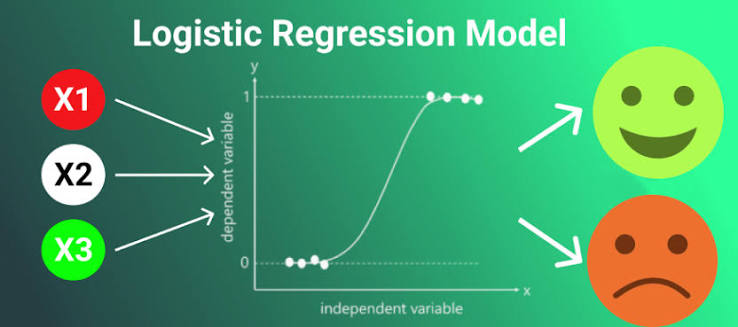

In [ ]:
# logistic regression -> binary classification
# based on an input X, the output is a predicted probability that X
# belongs to class 1 or 0, A or B etc.
# unlike the perceptron which simply directly classifying an input,
# log reg also provides a confidence level that an input is classified

## LOGISTIC REGRESSION IMPLEMENTATION V 1.0
## VERSION IS CONCEPTUALLY CORRECT BUT STILL MISSING A FEW MINOR DETAILS

import random
def gen_rand(low, up):
  return (low+(up-low)*random.random())

import math
def sigmoid(x):
  return 1/(1+math.exp(-x))

def sigmoid_activation(x):
  if x>=0.5:
    return 1
  else:
    return 0

class logistic_regression:
  # constructor and __repr__ for this class is identical to the perceptron
  def __init__(self, learning_rate=0.2,bias = 0.1, num_iters=10):
    # initialise all
    self.eta = learning_rate
    self.epochs = num_iters
    self.bias = bias
    self.weights = list() # weights are initialy an empty list

  def __repr__(self): # copied this dunder method implementation
                      # from google gemini to make model printing neater
        return f"logistic_regression(max_epochs={self.epochs}, learning_rate={self.eta}, bias={self.bias}, weights={self.weights})"

  # unlike a percetron, the forward method for
  # a log_reg model returns a probability rather than
  # a classification/step function result
  def forward(self, x): # x is a list of input feature values i.e x1, x2, ..., xn
      # net() [weighted sum]
      net = self.bias
      for i in range(len(x)):
        net=net+(x[i]*self.weights[i])

      # calling sigmoid() to calc probability of inputs belonging to class 1
      return sigmoid(net)

  def predict(self, x):
    return sigmoid_activation(self.forward(x)) # predict() method returns a class (1 or 0)
                                               # based on sigmoid_activation() func

  # accuracy method for model evaluation
  def accuracy(self, samples, y_act): # takes a list of samples 'samples' and list of
    correct = 0                       # target model outputs 'y_act' as an input. Returns accuracy
    for i in range(len(samples)):
      y_pred = self.predict(samples[i])
      if y_pred == y_act[i]: # if THIS prediction 'y_pred' is correct
        correct+=1
    return (correct/len(y_act)) # accuracy = correct_predictions/total_predictions

  def train(self, x, y): # x-> list of samples (list-of-lists). y-> list of outputs

    # initialise weights to some random number between -1 and 1
    self.weights = list() # weights list is dynamically redeclared and reinitialized
                          # every time train() is called since inputs are now given dynamically
                          # and num_weights = num_input_features
    for i in range(len(x[0])):
      self.weights.append(gen_rand(-1, 1))


     # iterate over epochs = 10
    for i in range(self.epochs):

      # iterate over samples
      for j in range(len(x)):

        # # new sample, new deltas
        # delta = list() ----> we are no longer storing deltas in a list.
        # it is now a temp var since there is no need to remember delta values in the long term

        # forward()
        y_pred = self.forward(x[j])


        # binary cross entropy loss (log loss)
        loss = -((y[j]*math.log(y_pred))+((1-y[j])*math.log(1-y_pred)))

        # error()
        error_signal = y_pred-y[j]

        # compute gradients
        # iterate over all feature weights
        for k in range(len(x[0])):
          gradient = error_signal*x[j][k]
          self.weights[k] = self.weights[k] - (self.eta*gradient) # gradient descent algo
        gradient = error_signal
        self.bias = self.bias - (self.eta*gradient)

      # for log_reg train() method, we also print
      # the binary cross entropy loss which should
      # ideally decrease with each iteration/epoch
      acc = self.accuracy(x, y)
      print('Epoch:', i)
      print('Loss', loss)
      print('Accuracy:',acc,'\n' )



if __name__=='__main__':
#   | Sample | Features | Target |
# | ------ | -------- | ------ |
# | 1      | [2,1]    | 1      |
# | 2      | [1,2]    | 1      |
# | 3      | [-1,-2]  | 0      |
# | 4      | [-2,-1]  | 0      |
  logreg_model = logistic_regression()
  logreg_model.train([
      [2, 1],
      [1, 2],
      [-1, -2],
      [-2, -1]
      ],
    [1, 1, 0, 0]
  )
  print(logreg_model)
  print('\n')

  print('[2, 1]:',logreg_model.predict([2, 1]))
  print('[1, 2]:',logreg_model.predict([1, 2]))
  print('[-1, -2]:',logreg_model.predict([-1, -2]))
  print('[-2, -1]:',logreg_model.predict([-2, -1]))





In [ ]:
# logistic regression -> binary classification
# based on an input X, the output is a predicted probability that X
# belongs to class 1 or 0, A or B etc.
# unlike the perceptron which simply directly classifying an input,
# log reg also provides a confidence level that an input is classified

## LOGISTIC REGRESSION IMPLEMENTATION V 2.0
## COMPLETE AND MATHEMATICALLY CORRECT VERSION
## FUTURE VERSIONS MAY EMPLOY MINI-BATCHES, NUMERICAL STABILITY, L2 REGULARIZATION, MOMENTUM, ADAM, VALIDATION SETS, ETC
## AND STORE LOSSES IN A LIST

import random
def gen_rand(low, up):
  return (low+(up-low)*random.random())

import math
def sigmoid(x):
  return 1/(1+math.exp(-x))

def sigmoid_activation(x):
  if x>=0.5:
    return 1
  else:
    return 0

class logistic_regression:
  # constructor and __repr__ for this class is identical to the perceptron
  def __init__(self, learning_rate=0.2,bias = 0.1, num_iters=10):
    # initialise all
    self.eta = learning_rate
    self.epochs = num_iters
    self.bias = bias
    self.weights = list() # weights are initialy an empty list

  def __repr__(self): # copied this dunder method implementation
                      # from google gemini to make model printing neater
        return f"logistic_regression(max_epochs={self.epochs}, learning_rate={self.eta}, bias={self.bias}, weights={self.weights})"

  # unlike a percetron, the forward method for
  # a log_reg model returns a probability rather than
  # a classification/step function result
  def forward(self, x): # x is a list of input feature values i.e x1, x2, ..., xn
      # net() [weighted sum]
      net = self.bias
      for i in range(len(x)):
        net=net+(x[i]*self.weights[i])

      # calling sigmoid() to calc probability of inputs belonging to class 1
      return sigmoid(net)

  def predict(self, x):
    return sigmoid_activation(self.forward(x)) # predict() method returns a class (1 or 0)
                                               # based on sigmoid_activation() func

  # accuracy method for model evaluation
  def accuracy(self, samples, y_act): # takes a list of samples 'samples' and list of
    correct = 0                       # target model outputs 'y_act' as an input. Returns accuracy
    for i in range(len(samples)):
      y_pred = self.predict(samples[i])
      if y_pred == y_act[i]: # if THIS prediction 'y_pred' is correct
        correct+=1
    return (correct/len(y_act)) # accuracy = correct_predictions/total_predictions

  def train(self, x, y): # x-> list of samples (list-of-lists). y-> list of outputs



    # initialise weights to some random number between -1 and 1
    self.weights = list() # weights list is dynamically redeclared and reinitialized
                          # every time train() is called since inputs are now given dynamically
                          # and num_weights = num_input_features
    for i in range(len(x[0])):
      self.weights.append(gen_rand(-1, 1))


     # iterate over epochs = 10
    for i in range(self.epochs):
      dataset_loss = 0 # initialize training loss to zero
                     # so we can calculate cost at the end of each epoch
                     # (this is a correction. V 1.0 only printed individual loss of the last sample at the end of each epoch)

      # iterate over samples
      for j in range(len(x)):

        # # new sample, new deltas
        # delta = list() ----> we are no longer storing deltas in a list.
        # it is now a temp var since there is no need to remember delta values in the long term

        # forward()
        y_pred = self.forward(x[j])


        # binary cross entropy loss (log loss)
        loss = -((y[j]*math.log(y_pred))+((1-y[j])*math.log(1-y_pred)))
        dataset_loss = dataset_loss+loss


        # error()
        error_signal = y_pred-y[j]

        # compute gradients
        # iterate over all feature weights
        for k in range(len(x[0])):
          gradient = error_signal*x[j][k]
          self.weights[k] = self.weights[k] - (self.eta*gradient) # gradient descent algo
        gradient = error_signal
        self.bias = self.bias - (self.eta*gradient)

      # for log_reg train() method, we also print
      # the binary cross entropy loss which should
      # ideally decrease with each iteration/epoch
      dataset_loss=dataset_loss/len(x) # sum_of_sample_losses/number_of_samples
      acc = self.accuracy(x, y)
      print('Epoch:', i)
      print('Loss', dataset_loss)
      print('Accuracy:',acc,'\n' )



if __name__=='__main__':
#   | Sample | Features | Target |
# | ------ | -------- | ------ |
# | 1      | [2,1]    | 1      |
# | 2      | [1,2]    | 1      |
# | 3      | [-1,-2]  | 0      |
# | 4      | [-2,-1]  | 0      |
  logreg_model = logistic_regression()
  logreg_model.train([
      [2, 1],
      [1, 2],
      [-1, -2],
      [-2, -1]
      ],
    [1, 1, 0, 0]
  )
  print(logreg_model)
  print('\n')

  print('[2, 1]:',logreg_model.predict([2, 1]))
  print('[1, 2]:',logreg_model.predict([1, 2]))
  print('[-1, -2]:',logreg_model.predict([-1, -2]))
  print('[-2, -1]:',logreg_model.predict([-2, -1]))





# Linear Algebra

In [ ]:
# IMPLEMENTING A MATRIX MULTIPLICATION FUNCTION FROM SCRATCH
# THIS FUNCTION IS NOT EXACTLY THE MOST EFFICIENT ALGORITHM TO WORK WITH
# BUT I AM AVOIDING RELYING SOLELY ON NUMPY SYNTAX TO DO MY DIRTY WORK FOR ME
# WILL IMPROVE THIS IMPLEMENTATION IN FUTURE VERSIONS

def mult_row_by_column(x, y): # both are lists but x is a row and y is column
                              # of the respective matrices they come from
  sum = 0
  for i in range(len(x)):
    sum = sum+ (x[i]*y[i])
  return sum # returns a

def col(b, col): # converts a column of a 2-d list/list-of-lists to a list
                 # 'col' is the index of the column we want to convert
  col_list =list()
  for i in range(len(b)):
      col_list.append(b[i][col]) # append the index of row i and column 'col' to list

  return col_list




def init_matrix(mat, len_a): # takes a list data type mat as input alongside
                             # number of rows of matrix a
  for i in range(len_a):
    mat.append([]) # rows of resultant matrix must equal rows of a matrix
                   # the columns of result will be handled automatically through
                   # the "multiply->add->append" logic of the nested loop in the
                   # mat_mult() function
  return mat




def mat_mult(a, b): # 'a' and 'b' are both matrices.
                    #  in this case we will represent matrices as a list-of-lists
  result = list() # 'result' could be another matrix (list-of-lists) or just a vector (list) depending on the input dimensions
  result = init_matrix(result, len(a))

# len(x) => number of rows
# len(x[0]) => number of columns
  if len(a[0]) != len(b): # if columns of a and rows of b are not equal
    print('Dimension mismatch. This is not a valid matrix multiplication')
    return
  for i in range(len(a)):
    for j in range(len(b[0])):
      # append this list to row i of the resultant list-of-lists
      result[i].append(mult_row_by_column(a[i], col(b, j)))
  return result

if __name__=='__main__':
  a = [[1, 0],
       [0, 1]]
  b = [[0, 1, 2],
       [1, -1, 3]]
  print(mat_mult(a, b))






In [ ]:
# IMPLEMENTING A MATRIX MULTIPLICATION FUNCTION FROM SCRATCH
# THIS FUNCTION IS NOT EXACTLY THE MOST EFFICIENT ALGORITHM TO WORK WITH
# BUT I AM AVOIDING RELYING SOLELY ON NUMPY SYNTAX TO DO MY DIRTY WORK FOR ME
# THIS IS THE SLIGHLTY IMPROVED VERSION WITH VALIDATION AND POLISHING
# THERE ARE STILL A FEW LOGICAL ISSUES AND EDGE CASES I HAVE YET TO
# HANDLE. WILL DO IN A FUTURE VERSION


# changed name to dot product as it is more mathematically accurate
def dot_product(x, y): # both are lists but x is a row and y is column
                              # of the respective matrices they come from
  total = 0
  for i in range(len(x)):
    total = total+ (x[i]*y[i])
  return total # returns a

def col(b, col): # converts a column of a 2-d list/list-of-lists to a list
                 # 'col' is the index of the column we want to convert
  col_list =list()
  for i in range(len(b)):
      col_list.append(b[i][col]) # append the index of row i and column 'col' to list

  return col_list




def init_matrix(len_a): # takes number of rows of matrix a as input
                        # returns an empty matrix with len(a) rows
  mat = list()

  for i in range(len_a):
    mat.append([]) # rows of resultant matrix must equal rows of a matrix
                   # the columns of result will be handled automatically through
                   # the "multiply->add->append" logic of the nested loop in the
                   # mat_mult() function
  return mat

def validate_matrices(a, b):
  if len(a[0]) != len(b): # if columns of a and rows of b are not equal
    print('Dimension mismatch. This is not a valid matrix multiplication')
    return False
  else:
    length_of_row_a = len(a[0])
    length_of_row_b = len(b[0])
    for i in range(len(a)):
      if len(a[i])!=length_of_row_a:
        print('Malformed Matrix a')
        return False
      else:
         if len(a[i])==0:
           print('Empty Row in a')
           return False
    for i in range(len(b)):
      if len(b[i])!=length_of_row_b:
        print('Malformed Matrix b')
        return False
      else:
         if len(b[i])==0:
           print('Empty Row in b')
           return False
    return True



def mat_mult(a, b): # 'a' and 'b' are both matrices.
                    #  in this case we will represent matrices as a list-of-lists
# len(x) => number of rows
# len(x[0]) => number of columns
  if validate_matrices(a, b):
    result = init_matrix(len(a)) # 'result' could be another matrix (list-of-lists) or just a vector (list) depending on the input dimensions
    for i in range(len(a)):
      for j in range(len(b[0])):
        # append this list to row i of the resultant list-of-lists
        result[i].append(dot_product(a[i], col(b, j)))
    return result


if __name__=='__main__':
  a = [[1, 0],
       [0, 1]]
  b = [[0, 1, 2],
       [1, -1, 3]]
  print(mat_mult(a, b))






In [ ]:

# IMPLEMENTING A MATRIX MULTIPLICATION FUNCTION FROM SCRATCH
# THIS FUNCTION IS NOT EXACTLY THE MOST EFFICIENT ALGORITHM TO WORK WITH
# BUT I AM AVOIDING RELYING SOLELY ON NUMPY SYNTAX TO DO MY DIRTY WORK FOR ME
# THIS IS THE SLIGHLTY IMPROVED VERSION WITH VALIDATION AND POLISHING
# FINAL VERSION WITH FIXED VALIDATOR FUNCTION


# changed name to dot product as it is more mathematically accurate
def dot_product(x, y): # both are lists but x is a row and y is column
                              # of the respective matrices they come from
  total = 0
  for i in range(len(x)):
    total = total+ (x[i]*y[i])
  return total # returns a

def col(b, col): # converts a column of a 2-d list/list-of-lists to a list
                 # 'col' is the index of the column we want to convert
  col_list =list()
  for i in range(len(b)):
      col_list.append(b[i][col]) # append the index of row i and column 'col' to list

  return col_list




def init_matrix(len_a): # takes number of rows of matrix a as input
                        # returns an empty matrix with len(a) rows
  mat = list()

  for i in range(len_a):
    mat.append([]) # rows of resultant matrix must equal rows of a matrix
                   # the columns of result will be handled automatically through
                   # the "multiply->add->append" logic of the nested loop in the
                   # mat_mult() function
  return mat

# chatGPT generated fixed validator
# im sorry god. i have failed you
def validate_matrices(a, b):

  # Matrix exists
  if len(a) == 0:
    print("Matrix a is empty")
    return False

  if len(b) == 0:
    print("Matrix b is empty")
    return False

  # First row exists and isn't empty
  if len(a[0]) == 0:
    print("Empty Row in a")
    return False

  if len(b[0]) == 0:
    print("Empty Row in b")
    return False

  length_of_row_a = len(a[0])
  length_of_row_b = len(b[0])

  # Check every row in A
  for i in range(len(a)):
    if len(a[i]) == 0:
      print("Empty Row in a")
      return False

    if len(a[i]) != length_of_row_a:
      print("Malformed Matrix a")
      return False

  # Check every row in B
  for i in range(len(b)):
    if len(b[i]) == 0:
      print("Empty Row in b")
      return False

    if len(b[i]) != length_of_row_b:
      print("Malformed Matrix b")
      return False

  # Finally, check multiplication compatibility
  if length_of_row_a != len(b):
    print("Dimension mismatch. This is not a valid matrix multiplication")
    return False

  return True



def mat_mult(a, b): # 'a' and 'b' are both matrices.
                    #  in this case we will represent matrices as a list-of-lists
# len(x) => number of rows
# len(x[0]) => number of columns
  if validate_matrices(a, b):
    result = init_matrix(len(a)) # 'result' could be another matrix (list-of-lists) or just a vector (list) depending on the input dimensions
    for i in range(len(a)):
      for j in range(len(b[0])):
        # append this list to row i of the resultant list-of-lists
        result[i].append(dot_product(a[i], col(b, j)))
    return result

## ADDITIONAL FUNCTION FOR MATRIX ADDITION
def mat_add(a, b):
  # len(x) => number of rows
# len(x[0]) => number of columns
  if len(a)  == len(b) and len(a[0]) == len(b[0]):
    result = init_matrix(len(a))
    for i in range(len(a)):
      for j in range(len(a[0])):
        result[i].append(a[i][j]+b[i][j])
  return result


if __name__=='__main__':
  a = [[1, 0],
       [0, 1]]
  b = [[0, 1, 2],
       [1, -1, 3]]
  print(mat_mult(a, b))

  a = [[1, 0], [0, 1]]
  b = [[1, 0], [0, 1]]
  print(mat_add(a, b))


In [ ]:

# IMPLEMENTING A MATRIX MULTIPLICATION FUNCTION FROM SCRATCH
# THIS FUNCTION IS NOT EXACTLY THE MOST EFFICIENT ALGORITHM TO WORK WITH
# BUT I AM AVOIDING RELYING SOLELY ON NUMPY SYNTAX TO DO MY DIRTY WORK FOR ME
# THIS IS THE SLIGHLTY IMPROVED VERSION WITH VALIDATION AND POLISHING
# FINAL VERSION WITH FIXED VALIDATOR FUNCTION


# changed name to dot product as it is more mathematically accurate
def dot_product(x, y): # both are lists but x is a row and y is column
                              # of the respective matrices they come from
  total = 0
  for i in range(len(x)):
    total = total+ (x[i]*y[i])
  return total # returns a

def col(b, col): # converts a column of a 2-d list/list-of-lists to a list
                 # 'col' is the index of the column we want to convert
  col_list =list()
  for i in range(len(b)):
      col_list.append(b[i][col]) # append the index of row i and column 'col' to list

  return col_list



# def init_matrix(len_a): # takes number of rows of matrix a as input
#                         # returns an empty matrix with len(a) rows
#   mat = list()

#   for i in range(len_a):
#     mat.append([]) # rows of resultant matrix must equal rows of a matrix
#                    # the columns of result will be handled automatically through
#                    # the "multiply->add->append" logic of the nested loop in the
#                    # mat_mult() function
#   return mat
def init_matrix(rows, cols): # takes number of rows and columns of matrix as input
                             # returns a zero matrix with same rows and columns
  mat = list()

  for i in range(rows):
    mat.append([])
    for j in range(cols):
      mat[i].append(0)
  return mat         # [0, 0, 0,....],
  #                     [0, 0, 0,....],
  #                     [0, 0, 0,....],

# chatGPT generated fixed validator
# im sorry god. i have failed you
def validate_matrices(a, b):

  # Matrix exists
  if len(a) == 0:
    print("Matrix a is empty")
    return False

  if len(b) == 0:
    print("Matrix b is empty")
    return False

  # First row exists and isn't empty
  if len(a[0]) == 0:
    print("Empty Row in a")
    return False

  if len(b[0]) == 0:
    print("Empty Row in b")
    return False

  length_of_row_a = len(a[0])
  length_of_row_b = len(b[0])

  # Check every row in A
  for i in range(len(a)):
    if len(a[i]) == 0:
      print("Empty Row in a")
      return False

    if len(a[i]) != length_of_row_a:
      print("Malformed Matrix a")
      return False

  # Check every row in B
  for i in range(len(b)):
    if len(b[i]) == 0:
      print("Empty Row in b")
      return False

    if len(b[i]) != length_of_row_b:
      print("Malformed Matrix b")
      return False

  # Finally, check multiplication compatibility
  if length_of_row_a != len(b):
    print("Dimension mismatch. This is not a valid matrix multiplication")
    return False

  return True



def mat_mult(a, b): # 'a' and 'b' are both matrices.
                    #  in this case we will represent matrices as a list-of-lists
# len(x) => number of rows
# len(x[0]) => number of columns
  if validate_matrices(a, b):
    result = init_matrix(len(a), len(b[0])) # 'result' could be another matrix (list-of-lists) or just a vector (list) depending on the input dimensions
    for i in range(len(a)):
      for j in range(len(b[0])):
        # append this list to row i of the resultant list-of-lists
        result[i][j]=(dot_product(a[i], col(b, j)))
    return result

## ADDITIONAL FUNCTION FOR MATRIX ADDITION
def mat_add(a, b):
  # len(x) => number of rows
# len(x[0]) => number of columns
  if len(a)  == len(b) and len(a[0]) == len(b[0]):
    result = init_matrix(len(a), len(a[0]))
    for i in range(len(a)):
      for j in range(len(a[0])):
        result[i][j]=(a[i][j]+b[i][j])
  return result


if __name__=='__main__':
  a = [[1, 0],
       [0, 1]]
  b = [[0, 1, 2],
       [1, -1, 3]]
  print(mat_mult(a, b))

  a = [[1, 0], [0, 1]]
  b = [[1, 0], [0, 1]]
  print(mat_add(a, b))


# Multilayer Perceptron
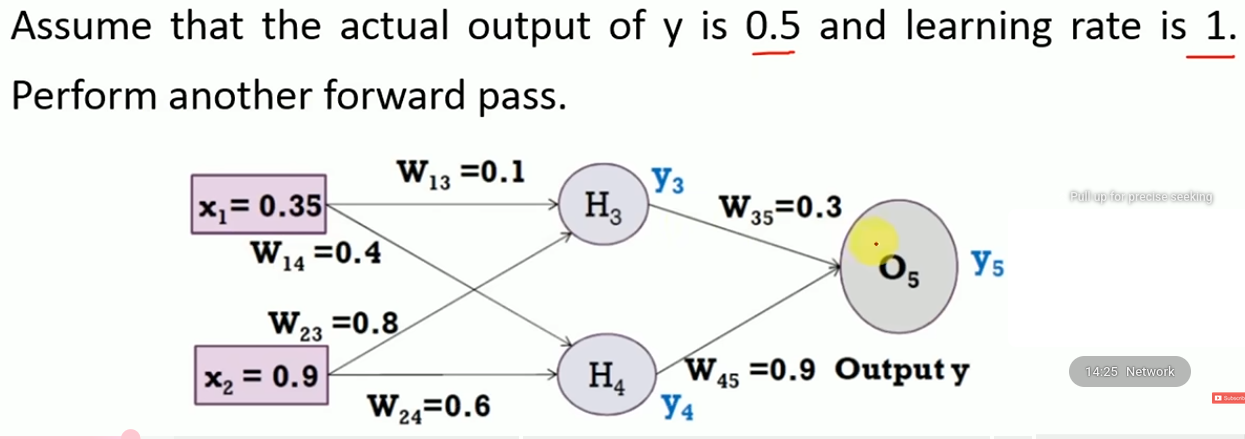

In [ ]:
## MULTILAYER PERCEPTRON IMPLEMENTATION V 1.0
## HARD CODED VERSION, WILL MAKE IT DYNAMIC IN THE NEXT CELL

import math
def sigmoid(x):
  return 1/(1+math.exp(-x))

class mlp:
  # initial values same as the example above
  # cuz im too retarded to figure out how to make this dynamic (again)
  epochs = 10
  eta = 1.0
  inputs = [
      [0.35],
      [0.9]
  ]
  weights = [     [
                   [0.1, 0.8],
                   [0.4, 0.6]
                  ],
                  
                  [
                    [0.3, 0.9]
                  ]
            ]
  bias = [0.0, 0.0] # bias for hidden layer and output layer respectively

  def __init__(self):
    pass

  def sigmoid(self, mat): # takes a vector as an input parameter and returns the
                          # sigmoid probability output vector
    mat_output=init_matrix(len(mat), len(mat[0]))
    for i in range(len(mat)):
      for j in range(len(mat[0])):
        mat_output[i][j] = sigmoid(mat[i][j])
    return mat_output



  def forward(self):

    # input layer to hidden layer
    w1 = self.weights[0]
    result1 = self.sigmoid(mat_mult(w1, self.inputs)+self.bias[0])

    # hidden layer to output layer
    w2 = self.weights[1]
    result2 = self.sigmoid(mat_mult(w2, result1)+self.bias[1])

    return result2


if __name__=='__main__':
  mlp = mlp()

  print(mlp.forward())
